In [ ]:
import json
from pathlib import Path
from typing import Dict, List, Tuple


def load_metric_data(
    base_dir: str,
    model_id: str,
    metric: str
) -> List[Tuple[float, float]]:
    """
    Load evaluation data for a specific metric.
    
    Args:
        base_dir: Base directory path (e.g., "eval/jailbreak")
        model_id: Model identifier (e.g., "Qwen/Qwen2.5-3B-Instruct")
        metric: Metric name (e.g., "substring", "llama_guard", "harmbench")
    
    Returns:
        List of (degree, score) tuples, sorted by degree
    """
    metric_dir = Path(base_dir) / model_id / metric
    
    if not metric_dir.exists():
        print(f"Warning: Directory not found: {metric_dir}")
        return []
    
    points = []
    # Pattern: results_degree_*_{metric}.json
    json_files = sorted(metric_dir.glob(f"results_degree_*_{metric}.json"))
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            degree = data.get("degree")
            metadata = data.get("metadata", {})
            score = metadata.get(metric)
            
            if degree is None or score is None:
                print(f"Warning: Missing data in {json_file.name} (degree={degree}, score={score})")
                continue
            
            points.append((float(degree), float(score)))
        
        except (json.JSONDecodeError, KeyError, ValueError) as e:
            print(f"Warning: Error reading {json_file.name}: {e}")
            continue
    
    return sorted(points, key=lambda x: x[0])


def load_all_metrics(
    base_dir: str,
    model_id: str,
    metrics: List[str]
) -> Dict[str, List[Tuple[float, float]]]:
    """
    Load evaluation data for all metrics.
    
    Args:
        base_dir: Base directory path (e.g., "eval/jailbreak")
        model_id: Model identifier (e.g., "Qwen/Qwen2.5-3B-Instruct")
        metrics: List of metric names to load
    
    Returns:
        Dictionary mapping metric names to lists of (degree, score) tuples
    """
    data_dict = {}
    
    for metric in metrics:
        points = load_metric_data(base_dir, model_id, metric)
        data_dict[metric] = points
        if points:
            print(f"Loaded {len(points)} data points for {metric}")
        else:
            print(f"No data points found for {metric}")
    
    return data_dict


Loaded 37 data points for substring
Loaded 37 data points for llama_guard
Loaded 37 data points for harmbench


{'substring': [(0.0, 0.9903846153846154),
  (10.0, 0.9903846153846154),
  (20.0, 0.9711538461538461),
  (30.0, 0.9423076923076923),
  (40.0, 0.9038461538461539),
  (50.0, 0.8942307692307693),
  (60.0, 0.5769230769230769),
  (70.0, 0.2403846153846154),
  (80.0, 0.14423076923076922),
  (90.0, 0.6730769230769231),
  (100.0, 0.625),
  (110.0, 0.4326923076923077),
  (120.0, 0.28846153846153844),
  (130.0, 0.2692307692307692),
  (140.0, 0.33653846153846156),
  (150.0, 0.5288461538461539),
  (160.0, 0.6538461538461539),
  (170.0, 0.6923076923076923),
  (180.0, 0.6730769230769231),
  (190.0, 0.5096153846153846),
  (200.0, 0.1346153846153846),
  (210.0, 0.0),
  (220.0, 0.0),
  (230.0, 0.009615384615384616),
  (240.0, 0.0),
  (250.0, 0.0),
  (260.0, 0.009615384615384616),
  (270.0, 0.38461538461538464),
  (280.0, 1.0),
  (290.0, 1.0),
  (300.0, 0.9711538461538461),
  (310.0, 0.9903846153846154),
  (320.0, 1.0),
  (330.0, 1.0),
  (340.0, 0.9903846153846154),
  (350.0, 0.9903846153846154),
  (360.

Loaded 37 data points for substring
Loaded 37 data points for llama_guard
Loaded 37 data points for harmbench
✅ Static image saved as qwen2.5-3b-instruct.png


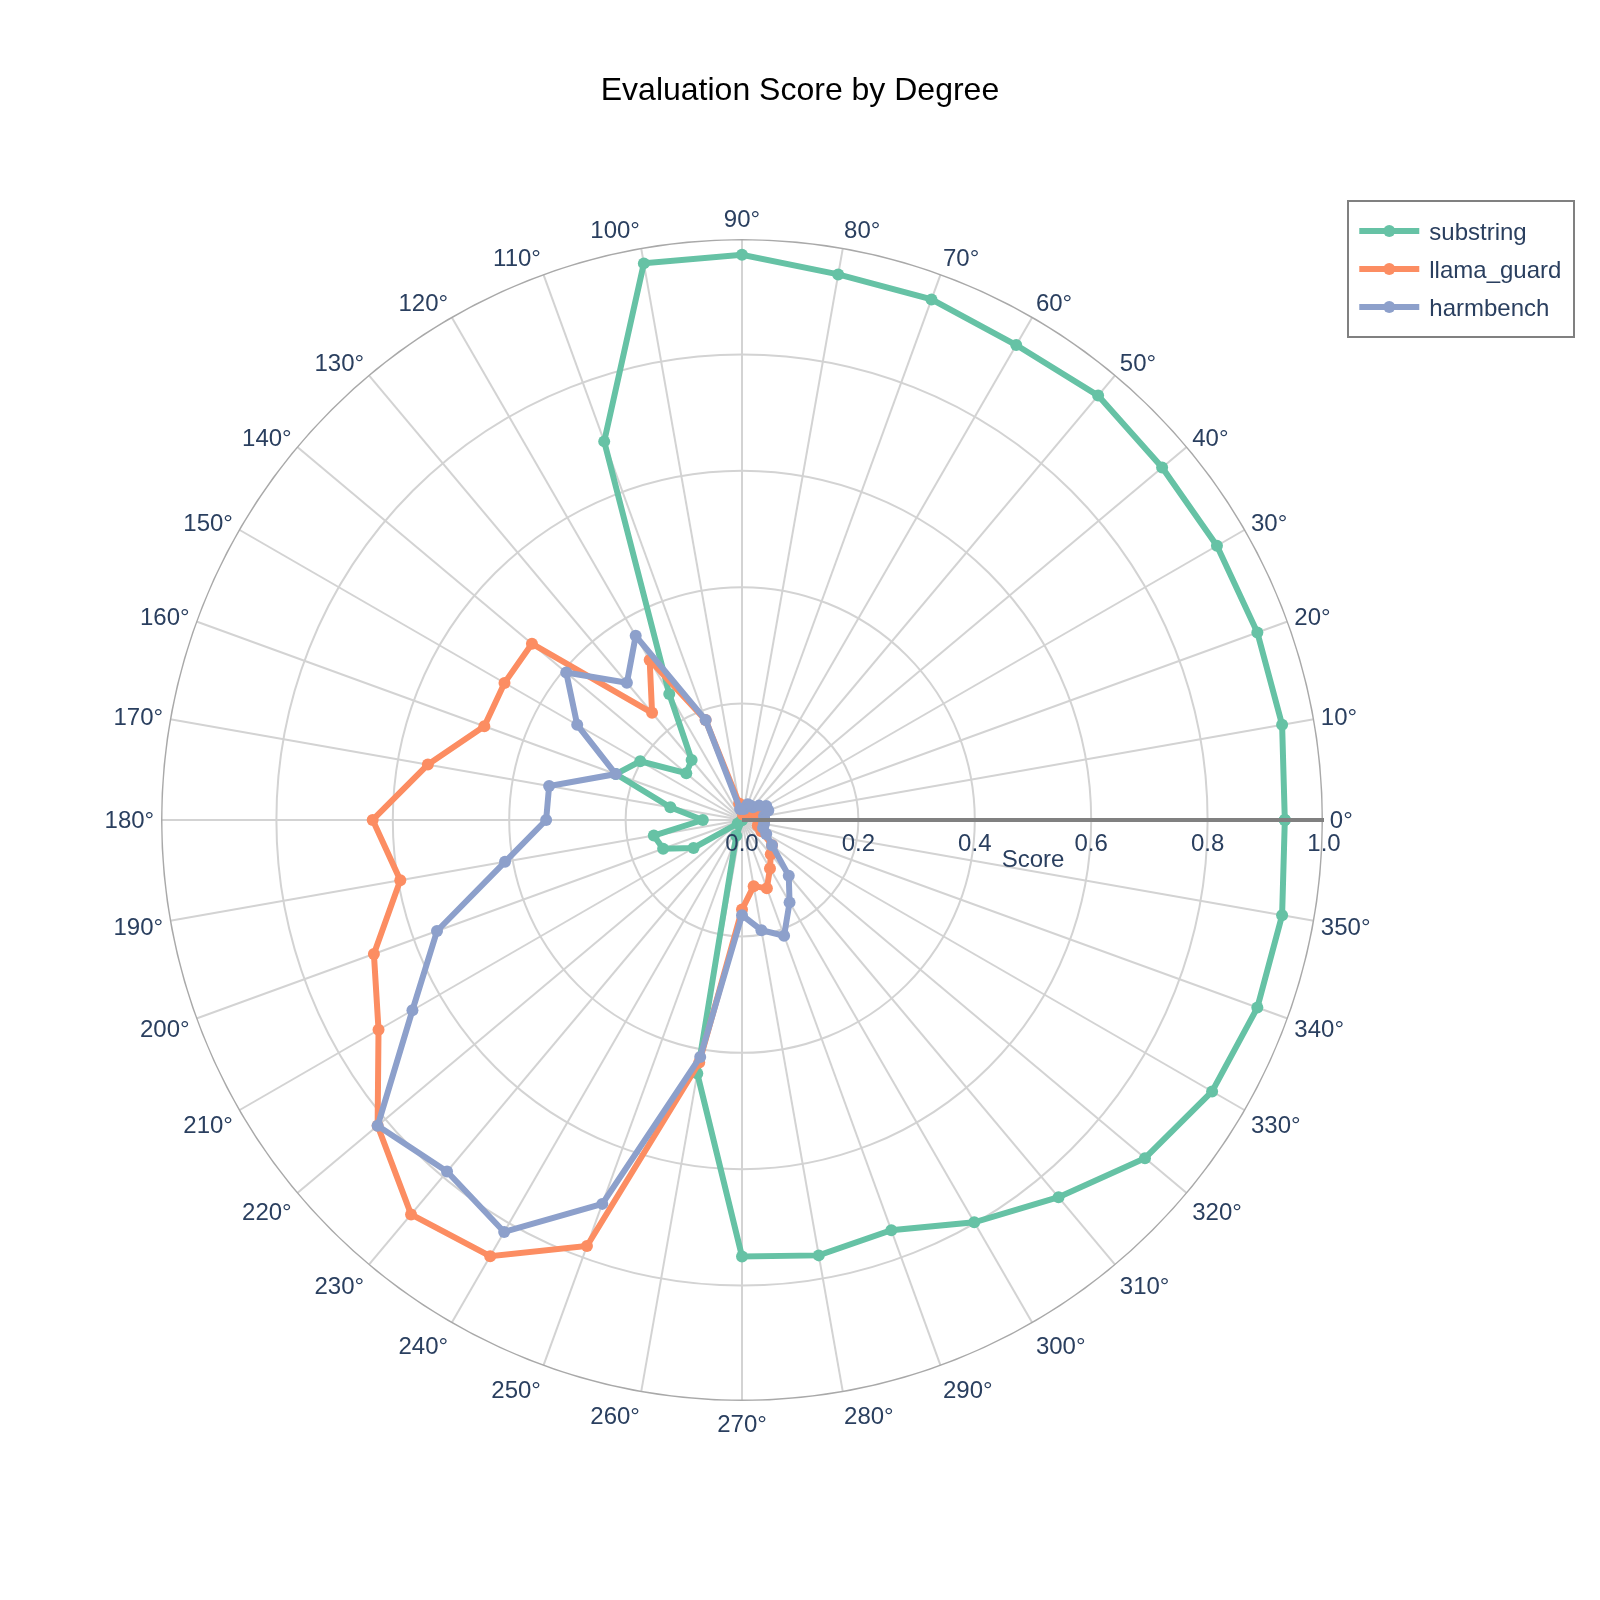

📊 Static image displayed for GitLab compatibility


In [8]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import numpy as np
from typing import Dict, List, Tuple
import plotly.colors as pc

def plot_spider_chart_plotly(
    data_dict: Dict[str, List[Tuple[float, float]]],
    width: int = 800,
    height: int = 800,
    title: str = None,
    save_static: bool = True,
    static_filename: str = "spider_chart.png"
):
    """
    Plot an interactive spider/radar chart with GitLab compatibility.
    
    Args:
        data_dict: Dictionary mapping metric names to lists of (degree, score) tuples
                  Scores should be in the range [0, 1]
        width: Figure width in pixels
        height: Figure height in pixels
        title: Custom title for the chart
        save_static: Whether to save static PNG for GitLab viewing
        static_filename: Filename for static image
    """
    # Extract unique degrees from all data series and sort them
    all_degrees = set()
    for points in data_dict.values():
        for degree, _ in points:
            all_degrees.add(degree)
    
    degrees = np.array(sorted(all_degrees))
    
    # Create figure
    fig = go.Figure()
    
    # Generate automatic colors using Plotly's color palette
    n_series = len(data_dict)
    colors = px.colors.qualitative.Set2[:n_series] if n_series <= len(px.colors.qualitative.Set2) else px.colors.qualitative.Plotly
    
    # Add outer boundary circle at radius 1.0 FIRST (so it appears as background)
    theta_circle = np.linspace(0, 360, 361)  # Full circle with 1-degree steps
    fig.add_trace(go.Scatterpolar(
        r=np.full_like(theta_circle, 1.0),
        theta=theta_circle,
        mode='lines',
        name='Max score (1.0)',
        line=dict(color='darkgray', width=2.5),
        showlegend=False,
        hoverinfo='skip'  # Don't show hover for the boundary circle
    ))
    
    for idx, (metric_name, points) in enumerate(data_dict.items()):
        # Create a dictionary for quick lookup
        point_dict = {degree: score for degree, score in points}
        
        # Extract scores in order of degrees
        scores = []
        theta_values = []
        for deg in degrees:
            if deg in point_dict:
                scores.append(point_dict[deg])
                theta_values.append(deg)
        
        scores = np.array(scores)
        theta_values = np.array(theta_values)
        
        # Sort data by theta for proper line connection
        sort_indices = np.argsort(theta_values)
        theta_sorted = theta_values[sort_indices]
        scores_sorted = scores[sort_indices]
        
        # Close the circle by appending the first point at the end
        theta_closed = np.append(theta_sorted, theta_sorted[0])
        scores_closed = np.append(scores_sorted, scores_sorted[0])
        
        # Add the main line trace (without fill)
        fig.add_trace(go.Scatterpolar(
            r=scores_closed,
            theta=theta_closed,
            mode='lines+markers',
            name=metric_name,
            line=dict(color=colors[idx % len(colors)], width=3),
            marker=dict(size=6, color=colors[idx % len(colors)]),
            hovertemplate=f'<b>{metric_name}</b><br>' +
                         'Degree: %{theta}°<br>' +
                         'Score: %{r:.3f}<br>' +
                         '<extra></extra>'
        ))
    
    # Create radial tick values from 0 to 1
    radial_ticks = np.linspace(0, 1, 6)  # 0, 0.2, 0.4, 0.6, 0.8, 1.0
    
    # Prepare degree labels (prioritize 0 over 360 if both exist)
    display_degrees = degrees.copy()
    if 0 in degrees and 360 in degrees:
        display_degrees = degrees[degrees != 360]  # Remove 360, keep 0
    
    # Update layout
    if title is None:
        title = 'Evaluation Score by Degree'
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1],
                tickvals=radial_ticks,
                ticktext=[f'{tick:.1f}' for tick in radial_ticks],
                title=dict(text='Score', font=dict(size=12)),
                gridcolor='lightgray',
                gridwidth=1,
                showline=True,
                linecolor='gray',
                linewidth=2,
            ),
            angularaxis=dict(
                tickvals=display_degrees,
                ticktext=[f'{int(d)}°' for d in display_degrees],
                direction='counterclockwise',
                rotation=0,  # Start from top
                gridcolor='lightgray',
                gridwidth=1,
            ),
            bgcolor='white'
        ),
        title=dict(
            text=title,
            x=0.5,
            font=dict(size=16, color='black'),
            pad=dict(t=20)
        ),
        showlegend=True,
        legend=dict(
            orientation="v",
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02,
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='gray',
            borderwidth=1
        ),
        width=width,
        height=height,
        paper_bgcolor='white',
        plot_bgcolor='white'
    )
    
    # GitLab Compatibility: Save static image
    if save_static:
        try:
            fig.write_image(static_filename, width=width, height=height, scale=2)
            print(f"✅ Static image saved as {static_filename}")
            
            # Display static image in Jupyter
            try:
                from IPython.display import Image, display
                display(Image(static_filename))
                print("📊 Static image displayed for GitLab compatibility")
            except ImportError:
                print("ℹ️ IPython not available, static image saved but not displayed")
                
        except Exception as e:
            print(f"⚠️ Could not save static image: {e}")
            print("💡 Install kaleido: pip install kaleido")
    
    return fig

# Configuration
METRICS = ["substring", "llama_guard", "harmbench"]
MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
BASE_DIR = "../logs/jailbreak/selective"

# Load all evaluation data
data_dict = load_all_metrics(BASE_DIR, MODEL_ID, METRICS)

# Create the plot
fig = plot_spider_chart_plotly(
    data_dict,
    width=800,
    height=800,
    save_static=True,
    static_filename="qwen2.5-3b-instruct.png"
)

# Show the plot
# fig.show()

# Optionally save as HTML
# fig.write_html("qwen2.5-3b-instruct.html")

##################################################
# Display the static image in notebook
# from IPython.display import Image, display
# display(Image("qwen2.5-3b-instruct.png"))

In [33]:
"""
Spider Chart Visualization for Jailbreak Evaluation
====================================================
Visualizes 3 methods × 3 metrics × multiple models

Structure:
- Each subplot = one model
- Each color = one metric (substring, llama_guard, harmbench)
- Each line style = one method (standard, adaptive, selective)
"""

import json
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import plotly.graph_objects as go
import numpy as np


# =============================================================================
# Data Loading Functions
# =============================================================================

def load_metric_data(
    base_dir: str,
    model_id: str,
    metric: str
) -> List[Tuple[float, float]]:
    """
    Load evaluation data for a specific metric.
    
    Args:
        base_dir: Base directory path (e.g., "eval/jailbreak/selective")
        model_id: Model identifier (e.g., "Qwen/Qwen2.5-3B-Instruct")
        metric: Metric name (e.g., "substring", "llama_guard", "harmbench")
    
    Returns:
        List of (degree, score) tuples, sorted by degree
    """
    metric_dir = Path(base_dir) / model_id / metric
    
    if not metric_dir.exists():
        return []
    
    points = []
    json_files = sorted(metric_dir.glob(f"results_degree_*_{metric}.json"))
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            degree = data.get("degree")
            metadata = data.get("metadata", {})
            score = metadata.get(metric)
            
            if degree is not None and score is not None:
                points.append((float(degree), float(score)))
        except (json.JSONDecodeError, KeyError, ValueError):
            continue
    
    return sorted(points, key=lambda x: x[0])


def load_method_data(
    base_dir: str,
    method: str,
    model_id: str,
    metrics: List[str]
) -> Dict[str, List[Tuple[float, float]]]:
    """
    Load all metrics for a specific method and model.
    
    Args:
        base_dir: Base directory (e.g., "../logs/jailbreak")
        method: Method name (e.g., "selective", "adaptive", "standard")
        model_id: Model identifier
        metrics: List of metric names
    
    Returns:
        Dictionary mapping metric names to (degree, score) tuples
    """
    method_dir = f"{base_dir}/{method}"
    data_dict = {}
    
    for metric in metrics:
        points = load_metric_data(method_dir, model_id, metric)
        data_dict[metric] = points
    
    return data_dict


def load_all_data(
    base_dir: str,
    methods: List[str],
    model_ids: List[str],
    metrics: List[str]
) -> Dict[str, Dict[str, Dict[str, List[Tuple[float, float]]]]]:
    """
    Load all data for all methods, models, and metrics.
    
    Returns:
        Nested dict: model_id -> method -> metric -> [(degree, score), ...]
    """
    all_data = {}
    
    for model_id in model_ids:
        all_data[model_id] = {}
        for method in methods:
            all_data[model_id][method] = load_method_data(
                base_dir, method, model_id, metrics
            )
    
    return all_data


def get_baseline_score(
    model_data: Dict[str, Dict[str, List[Tuple[float, float]]]],
    method: str = "selective",
    metric: str = None
) -> Optional[float]:
    """Get baseline score from specified method at degree 0."""
    if method not in model_data:
        return None
    
    method_data = model_data[method]
    if metric and metric in method_data:
        for degree, score in method_data[metric]:
            if degree == 0:
                return score
    return None



def plot_jailbreak_by_method(
    all_data: Dict[str, Dict[str, Dict[str, List[Tuple[float, float]]]]],
    methods: List[str],
    metrics: List[str],
    max_score: float = 1.0,
    save_filename: str = "jailbreak_by_method.png",
    fig_width: int = 1200,
    fig_height: int = 1400,
    scale: float = 3.0,
    n_cols: int = 4,
):
    """
    Layout: For each method, models are arranged in multiple rows.
    With 8 models and n_cols=4: 2 rows per method = 6 total rows.
    
    Args:
        all_data: Nested dict of model -> method -> metric -> data
        methods: List of method names
        metrics: List of metric names  
        max_score: Maximum score for radial axis
        save_filename: Output filename
        fig_width: Figure width
        fig_height: Figure height
        scale: Output resolution scale
        n_cols: Number of columns (models per row)
    """
    model_ids = list(all_data.keys())
    n_models = len(model_ids)
    n_methods = len(methods)
    
    # Calculate rows per method
    rows_per_method = (n_models + n_cols - 1) // n_cols  # e.g., 8 models, 4 cols = 2 rows
    total_rows = n_methods * rows_per_method  # e.g., 3 methods × 2 rows = 6 rows
    
    # Colors for metrics
    metric_colors = {
        "harmbench": "#1E90FF",
        "llama_guard": "#00CED1", 
        "substring": "#DC143C",
    }

    # Line properties
    line_width = 2.5
    baseline_width = 2
    
    fig = go.Figure()
    
    # Calculate domains
    margin_x = 0.06  # Left margin for method labels
    margin_y = 0.06  # Bottom margin for legend
    gap_x = 0.02
    gap_y = 0.03
    method_gap = 0.04  # Extra gap between method groups
    
    plot_w = (1.0 - margin_x - (n_cols - 1) * gap_x - 0.02) / n_cols
    # Account for method gaps
    available_height = 1.0 - margin_y - 0.04 - (n_methods - 1) * method_gap
    plot_h = (available_height - (total_rows - n_methods) * gap_y) / total_rows
    
    # Build domains: iterate by method, then by model position
    domains = {}  # (method, model_id) -> domain
    
    current_y = 1.0 - 0.03  # Start from top
    
    for method_idx, method in enumerate(methods):
        for local_row in range(rows_per_method):
            for col in range(n_cols):
                model_idx = local_row * n_cols + col
                if model_idx >= n_models:
                    continue
                
                model_id = model_ids[model_idx]
                
                x0 = margin_x + col * (plot_w + gap_x)
                x1 = x0 + plot_w
                y1 = current_y - local_row * (plot_h + gap_y)
                y0 = y1 - plot_h
                
                domains[(method, model_id)] = {"x": [x0, x1], "y": [y0, y1]}
        
        # Move to next method group
        current_y = current_y - rows_per_method * (plot_h + gap_y) - method_gap + gap_y
    
    legend_added = set()
    angular_ticks = np.arange(0, 360, 10)
    radial_max = max_score * 1.1
    radial_ticks = np.linspace(0, max_score, 6)
    
    polar_idx = 0
    for method in methods:
        for model_id in model_ids:
            if (method, model_id) not in domains:
                continue
                
            polar_idx += 1
            polar_key = f"polar{polar_idx}" if polar_idx > 1 else "polar"
            domain = domains[(method, model_id)]
            
            model_data = all_data.get(model_id, {})
            method_data = model_data.get(method, {})
            
            # Background
            theta_bg = np.linspace(0, 360, 73)
            fig.add_trace(go.Scatterpolar(
                r=np.full_like(theta_bg, radial_max),
                theta=theta_bg,
                mode='lines',
                fill='toself',
                fillcolor='rgba(240, 248, 255, 0.5)',
                line=dict(color='rgba(0,0,0,0)', width=0),
                showlegend=False,
                subplot=polar_key,
            ))
            
            # Plot metrics
            for metric in metrics:
                if metric not in method_data or not method_data[metric]:
                    continue
                
                points = method_data[metric]
                color = metric_colors.get(metric, "#666666")
                
                degrees = np.array([p[0] for p in points])
                scores = np.array([p[1] for p in points])
                
                sort_idx = np.argsort(degrees)
                theta_sorted = degrees[sort_idx]
                scores_sorted = scores[sort_idx]
                scores_capped = np.minimum(scores_sorted, max_score)
                exceed_mask = scores_sorted > max_score
                
                theta_closed = np.append(theta_sorted, theta_sorted[0])
                scores_closed = np.append(scores_capped, scores_capped[0])
                
                show_legend = metric not in legend_added
                if show_legend:
                    legend_added.add(metric)
                
                fig.add_trace(go.Scatterpolar(
                    r=scores_closed,
                    theta=theta_closed,
                    mode='lines',
                    name=metric,
                    line=dict(color=color, width=line_width),
                    showlegend=show_legend,
                    legendgroup=metric,
                    subplot=polar_key,
                ))
                
                if np.any(exceed_mask):
                    exceed_theta = theta_sorted[exceed_mask]
                    fig.add_trace(go.Scatterpolar(
                        r=np.full_like(exceed_theta, max_score, dtype=float),
                        theta=exceed_theta,
                        mode='markers',
                        marker=dict(symbol='star', size=14, color='red'),
                        showlegend=False,
                        subplot=polar_key,
                    ))
            
            fig.update_layout(**{
                polar_key: dict(
                    domain=domain,
                    radialaxis=dict(
                        visible=True,
                        range=[0, radial_max],
                        tickvals=radial_ticks,
                        ticktext=[f'{t:.1f}' for t in radial_ticks],
                        tickfont=dict(size=14, color='#666'),
                        gridcolor='#d0d0d0',
                        gridwidth=0.4,
                    ),
                    angularaxis=dict(
                        tickvals=angular_ticks,
                        ticktext=[f'{int(d)}°' for d in angular_ticks],
                        tickfont=dict(size=14, color='#666'),
                        direction='counterclockwise',
                        rotation=0,
                        gridcolor='#d0d0d0',
                        gridwidth=0.3,
                    ),
                    bgcolor='white',
                )
            })
    
    # Add annotations
    annotations = []
    
    # Model names above each subplot
    for method, model_id in domains.keys():
        domain = domains[(method, model_id)]
        short_name = model_id.split('/')[-1]
        annotations.append(dict(
            text=f"<b>{short_name}</b>",
            x=(domain["x"][0] + domain["x"][1]) / 2,
            y=domain["y"][1] + 0.008,
            xref="paper", yref="paper",
            showarrow=False,
            font=dict(size=18, color='black'),
            xanchor="center", yanchor="bottom",
        ))
    
    # Method names on left (once per method group)
    for method_idx, method in enumerate(methods):
        # Find first model in this method to get y position
        first_model = model_ids[0]
        last_model_idx = min(rows_per_method * n_cols - 1, n_models - 1)
        last_model = model_ids[last_model_idx]
        
        if (method, first_model) in domains and (method, last_model) in domains:
            top_domain = domains[(method, first_model)]
            # Find bottom domain for this method
            bottom_model = model_ids[min((rows_per_method - 1) * n_cols, n_models - 1)]
            if (method, bottom_model) in domains:
                bottom_domain = domains[(method, bottom_model)]
                y_center = (top_domain["y"][1] + bottom_domain["y"][0]) / 2
            else:
                y_center = (top_domain["y"][0] + top_domain["y"][1]) / 2
            
            annotations.append(dict(
                text=f"<b>{method.capitalize()}</b>",
                x=0.01,
                y=y_center,
                xref="paper", yref="paper",
                showarrow=False,
                font=dict(size=20, color='black'),
                xanchor="left", yanchor="middle",
                textangle=-90,
            ))
    
    fig.update_layout(
        annotations=annotations,
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.01,
            xanchor="center",
            x=0.5,
            font=dict(size=18),
            bgcolor='rgba(255,255,255,0.95)',
        ),
        width=fig_width,
        height=fig_height,
        paper_bgcolor='white',
        margin=dict(t=20, b=50, l=50, r=20),
    )
    
    try:
        fig.write_image(save_filename, width=fig_width, height=fig_height, scale=scale)
        print(f"✅ Figure saved as {save_filename}")
    except Exception as e:
        print(f"⚠️ Error: {e}")
    
    return fig



In [34]:
# =============================================================================
# Configuration
# =============================================================================

METHODS = ["adaptive", "selective"]
METRICS = ["harmbench", "llama_guard", "substring"]
BASE_DIR = "../logs/jailbreak"

MODEL_IDS = [
    # Row 1: Qwen models
    # "Qwen/Qwen2.5-1.5B-Instruct",
    # "Qwen/Qwen2.5-3B-Instruct",
    # "Qwen/Qwen2.5-7B-Instruct",
    # # Row 2: Llama + Gemma
    # "meta-llama/Llama-3.2-1B-Instruct",
    "meta-llama/Llama-3.2-3B-Instruct",
    "meta-llama/Llama-3.1-8B-Instruct",
    "google/gemma-2-2b-it",
    "google/gemma-2-9b-it",
]



if __name__ == "__main__":
    # Use demo data for testing
    all_data = load_all_data(BASE_DIR, METHODS, MODEL_IDS, METRICS)
    methods = METHODS
    metrics = METRICS
    
    # By method layout: 3 rows (methods) × 8 columns (models)
    fig = plot_jailbreak_by_method(
        all_data=all_data,
        methods=methods,
        metrics=metrics,
        max_score=1.0,
        save_filename="jailbreak_spider.png",
        fig_width=2000,   # Wider for 8 models
        fig_height=1400,
        scale=3.0,
    )
    
    print("✅ Done!")

✅ Figure saved as jailbreak_spider.png
✅ Done!
